# Comparadores de imagem

- SSIM
- LIPS
- FID (Fréchet Inception Distance)
- NIQE - Natural Image Quality Evaluator (Uma imagem por vez) Quão real a imagem é

In [ ]:
# Imports
import torch
from canon.T4.utils import load_image_and_masks
from canon.T4.metrics.metrics import LPIPS, SSIM, FID, NIQE

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")


Dispositivo: cpu


/home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/.venv/lib/python3.10/site-packages/torchvision/transforms/functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


## LPIPS

In [ ]:
img1, masks = load_image_and_masks("antiga_1")
img2, masks = load_image_and_masks("antiga_2")

# LPIPS distance
d = LPIPS(img1, img2)

print(f"LPIPS distance: {d}")


/home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS distance: 0.6987934708595276


/home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/.venv/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


## SSIM

Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
SSIM: 0.41077402935899765


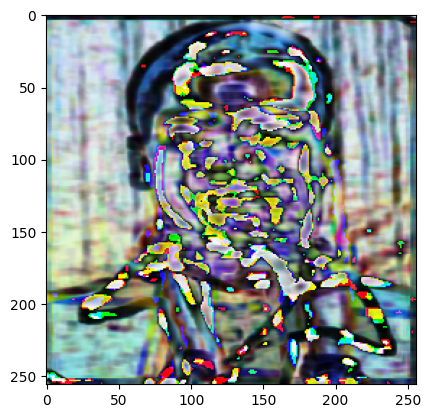

In [3]:
import matplotlib.pyplot as plt

img1, masks = load_image_and_masks("antiga_1")
img2, masks = load_image_and_masks("antiga_2")

(score, diff) = SSIM(img1, img2)

print(f"SSIM: {score}")
plt.imshow(diff) #Cenas do apocalipse

## NIQE

In [ ]:
img1, masks = load_image_and_masks("antiga_1")
niqeResult = NIQE(img1, crop_border=True)

print(niqeResult)

Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
8.670918417636702


## FID

NOTA: 
- Compara um conjunto de imagens reais vs imagens geradas de forma média entre cada conjunto. Não misture imagens reais e geradas no mesmo conjunto. 

- Bem mais pesado, se possivel rodar em GPU.

Formula geral:
d^2 = ||mu_1 – mu_2||^2 + Tr(C_1 + C_2 – 2*sqrt(C_1*C_2))


In [ ]:
img1, masks = load_image_and_masks("antiga_1")
img2, masks = load_image_and_masks("antiga_2")
img3, masks = load_image_and_masks("antiga_3")
img4, masks = load_image_and_masks("antiga_4")

realSet = [img1, img2]
genSet = [img3, img4]

score =  FID(realSet, genSet)

print(f"FID Score: {score}")

Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4
Reading from /home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/data/T4


/home/jevs/Documents/UNICAMP/2025-2s/MC949+MO446 - Visao Computacional/MC949-Visao-Computacional/.venv/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


FID Score: 538.6087330253786
